# Plot R ggtree circular phylogenetic trees 

- This notebook generates circular phylogenetic trees with R ggtree (aesthetically look better than the python ete3 default plot)
- Reproduce the RETrace2 in vitro benchmarking in microsatellite-stable cell line 3T3L1

## Requirements:
- Newick tree file
- CSV samplesheet with columns: sample_id, color, group



## 1. Setup and Package Installation


In [1]:
# Install required packages if not already installed
# Uncomment the lines below if you need to install packages

# if (!requireNamespace("BiocManager", quietly = TRUE))
#     install.packages("BiocManager") 
# 
# install.packages(c("ape", "dplyr", "ggplot2"))
# BiocManager::install(c("ggtree", "ggtreeExtra"))


In [2]:
# Load required libraries
suppressPackageStartupMessages({
  library(ggtree)
  library(ggtreeExtra)
  library(ape)
  library(dplyr)
  library(ggplot2)
})


## 2. Configuration Parameters

Adjust these parameters to customize your visualization:


## Microsatellite-stable cell 3T3L1 Dataset Visualization

In [3]:
# Configuration parameters - MODIFY THESE AS NEEDED

# File paths - choose your dataset
SAMPLESHEET_FILE <- "/home/tcheng/Projects/RETrace/20240319_AVITI_RETrace2_3T3L1_Tree_Nextflow/20240319_3T3L1_samplesheet.csv"
TREE_FILE <- "/home/tcheng/Projects/RETrace/20240319_AVITI_RETrace2_3T3L1_Tree_Nextflow/results_10000targets_3000cpgs_minqual0.9/phylo/20240319_3T3L1.buildPhylo.newick-original.txt"
OUTPUT_PREFIX <- "20240319_3T3L1_10000targets_minqual0.9_circular_ggtree"

# Visual parameters
COLOR_BACKGROUND <- FALSE  # Set to TRUE to apply colors to text background instead of node circles
PLOT_WIDTH <- 16
PLOT_HEIGHT <- 12
DPI <- 500
TIP_LABEL_SIZE <- 3.7
NODE_SIZE <- 3
LEGEND_TEXT_SIZE <- 22
LEGEND_TITLE_SIZE <- 24

# Ring parameters
INNER_RING_OFFSET <- 1.6
RING_WIDTH <- 4

cat("Configuration set:\n")
cat("Samplesheet:", SAMPLESHEET_FILE, "\n")
cat("Tree file:", TREE_FILE, "\n")
cat("Output prefix:", OUTPUT_PREFIX, "\n")
cat("Color background:", COLOR_BACKGROUND, "\n")


Configuration set:
Samplesheet: /home/tcheng/Projects/RETrace/20240319_AVITI_RETrace2_3T3L1_Tree_Nextflow/20240319_3T3L1_samplesheet.csv 
Tree file: /home/tcheng/Projects/RETrace/20240319_AVITI_RETrace2_3T3L1_Tree_Nextflow/results_10000targets_3000cpgs_minqual0.9/phylo/20240319_3T3L1.buildPhylo.newick-original.txt 
Output prefix: 20240319_3T3L1_10000targets_minqual0.9_circular_ggtree 
Color background: FALSE 


## 3. Data Loading and Preprocessing


In [4]:
# Load tree
tree <- read.tree(TREE_FILE)

cat("Tree loaded successfully!\n")
cat("Number of tips:", length(tree$tip.label), "\n")
cat("Tree type:", class(tree), "\n")

# Display first few tip labels
cat("\nFirst 10 tip labels:\n")
print(head(tree$tip.label, 10))


Tree loaded successfully!
Number of tips: 72 
Tree type: phylo 

First 10 tip labels:
 [1] "0-1-10D_1-1-4F_Plate1-10B" "0-1-10D_1-1-4F_Plate1-12D"
 [3] "0-1-10D_1-1-4F_Plate1-10D" "0-1-10D_1-1-4F_Plate1-10E"
 [5] "0-1-10D_1-1-4F_Plate1-12G" "0-1-10D_1-1-4F_Plate1-11D"
 [7] "0-1-10D_1-1-4F_Plate1-11E" "0-1-10D_1-1-4F_Plate1-11C"
 [9] "0-1-10D_1-2-2B_Plate1-1D"  "0-1-10D_1-1-4F_Plate1-12B"


In [5]:
# Load sample data
samples <- read.csv(SAMPLESHEET_FILE, stringsAsFactors = FALSE)

cat("Sample data loaded successfully!\n")
cat("Number of samples:", nrow(samples), "\n")
cat("Columns:", colnames(samples), "\n")

# Display first few rows
cat("\nFirst few rows of sample data:\n")
print(head(samples))

# Check for unique groups
cat("\nUnique groups:\n")
print(unique(samples$group))


Sample data loaded successfully!
Number of samples: 72 
Columns: sample_id ms_fastq_1 meth_fastq_1 group color 

First few rows of sample data:
                  sample_id
1 0-1-10D_1-1-4F_Plate1-10B
2 0-1-10D_1-1-4F_Plate1-10C
3 0-1-10D_1-1-4F_Plate1-10D
4 0-1-10D_1-1-4F_Plate1-10E
5 0-1-10D_1-1-4F_Plate1-10F
6 0-1-10D_1-1-4F_Plate1-10G
                                                                                                                                                                        ms_fastq_1
1 /datasets/s3/altos-lab-kzhang/tcheng/retrace2-data-seqraw/20240319_AVITI_RETrace2_3T3L1_Tree/0_Raw_Data/Fastq/MS_1nt169k_3T3L1_SC_0-1-10D_1-1-4F_20240319_Plate1-10B_R1.fastq.gz
2 /datasets/s3/altos-lab-kzhang/tcheng/retrace2-data-seqraw/20240319_AVITI_RETrace2_3T3L1_Tree/0_Raw_Data/Fastq/MS_1nt169k_3T3L1_SC_0-1-10D_1-1-4F_20240319_Plate1-10C_R1.fastq.gz
3 /datasets/s3/altos-lab-kzhang/tcheng/retrace2-data-seqraw/20240319_AVITI_RETrace2_3T3L1_Tree/0_Raw_Data/Fastq/MS_1nt169k_

In [6]:
# Handle missing values with defaults
if (!'color' %in% colnames(samples)) {
  samples$color <- 'grey'
  cat("Added default 'color' column\n")
} else {
  samples$color <- ifelse(is.na(samples$color) | samples$color == '', 'grey', samples$color)
  cat("Processed 'color' column\n")
}

# Display updated sample data
cat("\nSample data structure:\n")
print(str(samples))


Processed 'color' column

Sample data structure:
'data.frame':	72 obs. of  5 variables:
 $ sample_id   : chr  "0-1-10D_1-1-4F_Plate1-10B" "0-1-10D_1-1-4F_Plate1-10C" "0-1-10D_1-1-4F_Plate1-10D" "0-1-10D_1-1-4F_Plate1-10E" ...
 $ ms_fastq_1  : chr  "/datasets/s3/altos-lab-kzhang/tcheng/retrace2-data-seqraw/20240319_AVITI_RETrace2_3T3L1_Tree/0_Raw_Data/Fastq/M"| __truncated__ "/datasets/s3/altos-lab-kzhang/tcheng/retrace2-data-seqraw/20240319_AVITI_RETrace2_3T3L1_Tree/0_Raw_Data/Fastq/M"| __truncated__ "/datasets/s3/altos-lab-kzhang/tcheng/retrace2-data-seqraw/20240319_AVITI_RETrace2_3T3L1_Tree/0_Raw_Data/Fastq/M"| __truncated__ "/datasets/s3/altos-lab-kzhang/tcheng/retrace2-data-seqraw/20240319_AVITI_RETrace2_3T3L1_Tree/0_Raw_Data/Fastq/M"| __truncated__ ...
 $ meth_fastq_1: chr  "/datasets/s3/altos-lab-kzhang/tcheng/retrace2-data-seqraw/20240319_AVITI_RETrace2_3T3L1_Tree/0_Raw_Data/Fastq/M"| __truncated__ "/datasets/s3/altos-lab-kzhang/tcheng/retrace2-data-seqraw/20240319_AVITI_RETrace

## 4. Data Preparation for Visualization


In [7]:
# Prepare data for tree - only color column for tip labels
tip_label_data <- samples %>% 
  select(sample_id, color) %>%
  rename(label = sample_id)
rownames(tip_label_data) <- tip_label_data$label

# Prepare data for inner ring with group names for legend
group_ring_data <- samples %>%
  select(sample_id, color, group) %>%
  rename(label = sample_id)

cat("Data preparation completed!\n")
cat("Tip label data rows:", nrow(tip_label_data), "\n")
cat("Group ring data rows:", nrow(group_ring_data), "\n")


Data preparation completed!
Tip label data rows: 72 
Group ring data rows: 72 


In [8]:
# Custom rename dictionary for group names (customize as needed)
rename_dict <- list(
  'Brain_LeftAnteriorCortex' = 'Brain Left Anterior Cortex',
  'Brain_LeftPosteriorCortex' = 'Brain Left Posterior Cortex',
  'Kidney_Left-Cortex-1' = 'Kidney Left Cortex',
  'Kidney_Right-Cortex-1' = 'Kidney Right Cortex',
  'Liver_LeftLobe' = 'Liver Left Lobe',
  'Liver_MedianLobe' = 'Liver Median Lobe',
  'Liver_RightLobe' = 'Liver Right Lobe'
)

# Function to rename based on dictionary, leave unchanged if not in dict
rename_labels <- function(x, dict) {
  sapply(x, function(name) {
    if (name %in% names(dict)) {
      dict[[name]]
    } else {
      name
    }
  })
}

# Apply custom renaming to group names
group_names_clean <- rename_labels(unique(samples$group), rename_dict)
group_colors_map <- setNames(unique(samples$color), group_names_clean)

# Update the group_ring_data to use cleaned names
group_ring_data$group <- rename_labels(group_ring_data$group, rename_dict)

cat("Label cleaning completed!\n")
cat("Group colors map:\n")
print(group_colors_map)


Label cleaning completed!
Group colors map:
0-1-10D_1-1-4F 0-1-10D_1-2-2B 0-1-10D_1-2-6G 0-1-10D_1-2-7F 
     "#678AB8"      "#E68A87"      "#E8A87C"      "#8DA585" 


## 5. Tree Visualization


In [9]:
# Set plot size for notebook display
options(repr.plot.width = 12, repr.plot.height = 10, repr.plot.res = 150)

# Basic tree plot - circular layout only
p <- ggtree(tree, layout = 'circular', branch.length = 'none', size = 1)

# Join ONLY color data to tree for tip labels
p <- p %<+% tip_label_data

cat("Basic tree structure created!\n")


Basic tree structure created!


In [10]:
# Add tip labels with or without background color
if (COLOR_BACKGROUND) {
  # Text with colored background - smaller font to avoid overlap
  p <- p + geom_tiplab(aes(fill = color), 
                       size = TIP_LABEL_SIZE, color = 'black', 
                       geom = 'label', 
                       label.padding = unit(0.1, "lines")) +
    scale_fill_identity()
  cat("Added colored background tip labels\n")
} else {
  # Colored node circles with plain text - smaller font with offset
  p <- p + geom_tippoint(aes(color = color), size = NODE_SIZE) +
    geom_tiplab(size = TIP_LABEL_SIZE, offset = 0.6) +  # Small offset to push text away from nodes
    scale_color_identity()
  cat("Added colored node circles with plain text labels\n")
}


Added colored node circles with plain text labels


In [11]:
# Add inner continuous ring for group color with legend
p <- p + geom_fruit(
    data = group_ring_data,
    geom = geom_tile,
    mapping = aes(y = label, x = 2, fill = group),
    pwidth = 0.1,
    width = RING_WIDTH,
    offset = INNER_RING_OFFSET
  ) + 
  scale_fill_manual(
    values = group_colors_map,
    name = "3T3L1 Clone",  # <-- CHANGE THIS to your desired title
    guide = guide_legend(
      keyheight = unit(2, "lines"),  # <-- ADD THIS for more row spacing
      keywidth = unit(1, "lines"),   # <-- ADD THIS for wider keys
      label.position = "right",        # <-- ADD THIS for text position
      byrow = TRUE                     # <-- ADD THIS for row arrangement
    )
    # To turn OFF legend completely, replace the guide_legend(...) above with:
    # guide = "none"
  )

cat("Added inner ring for group colors\n")


! The following column names/name: color are/is the same to tree data, the tree data column names are : label, y, angle, color.



Added inner ring for group colors


Applied final theming


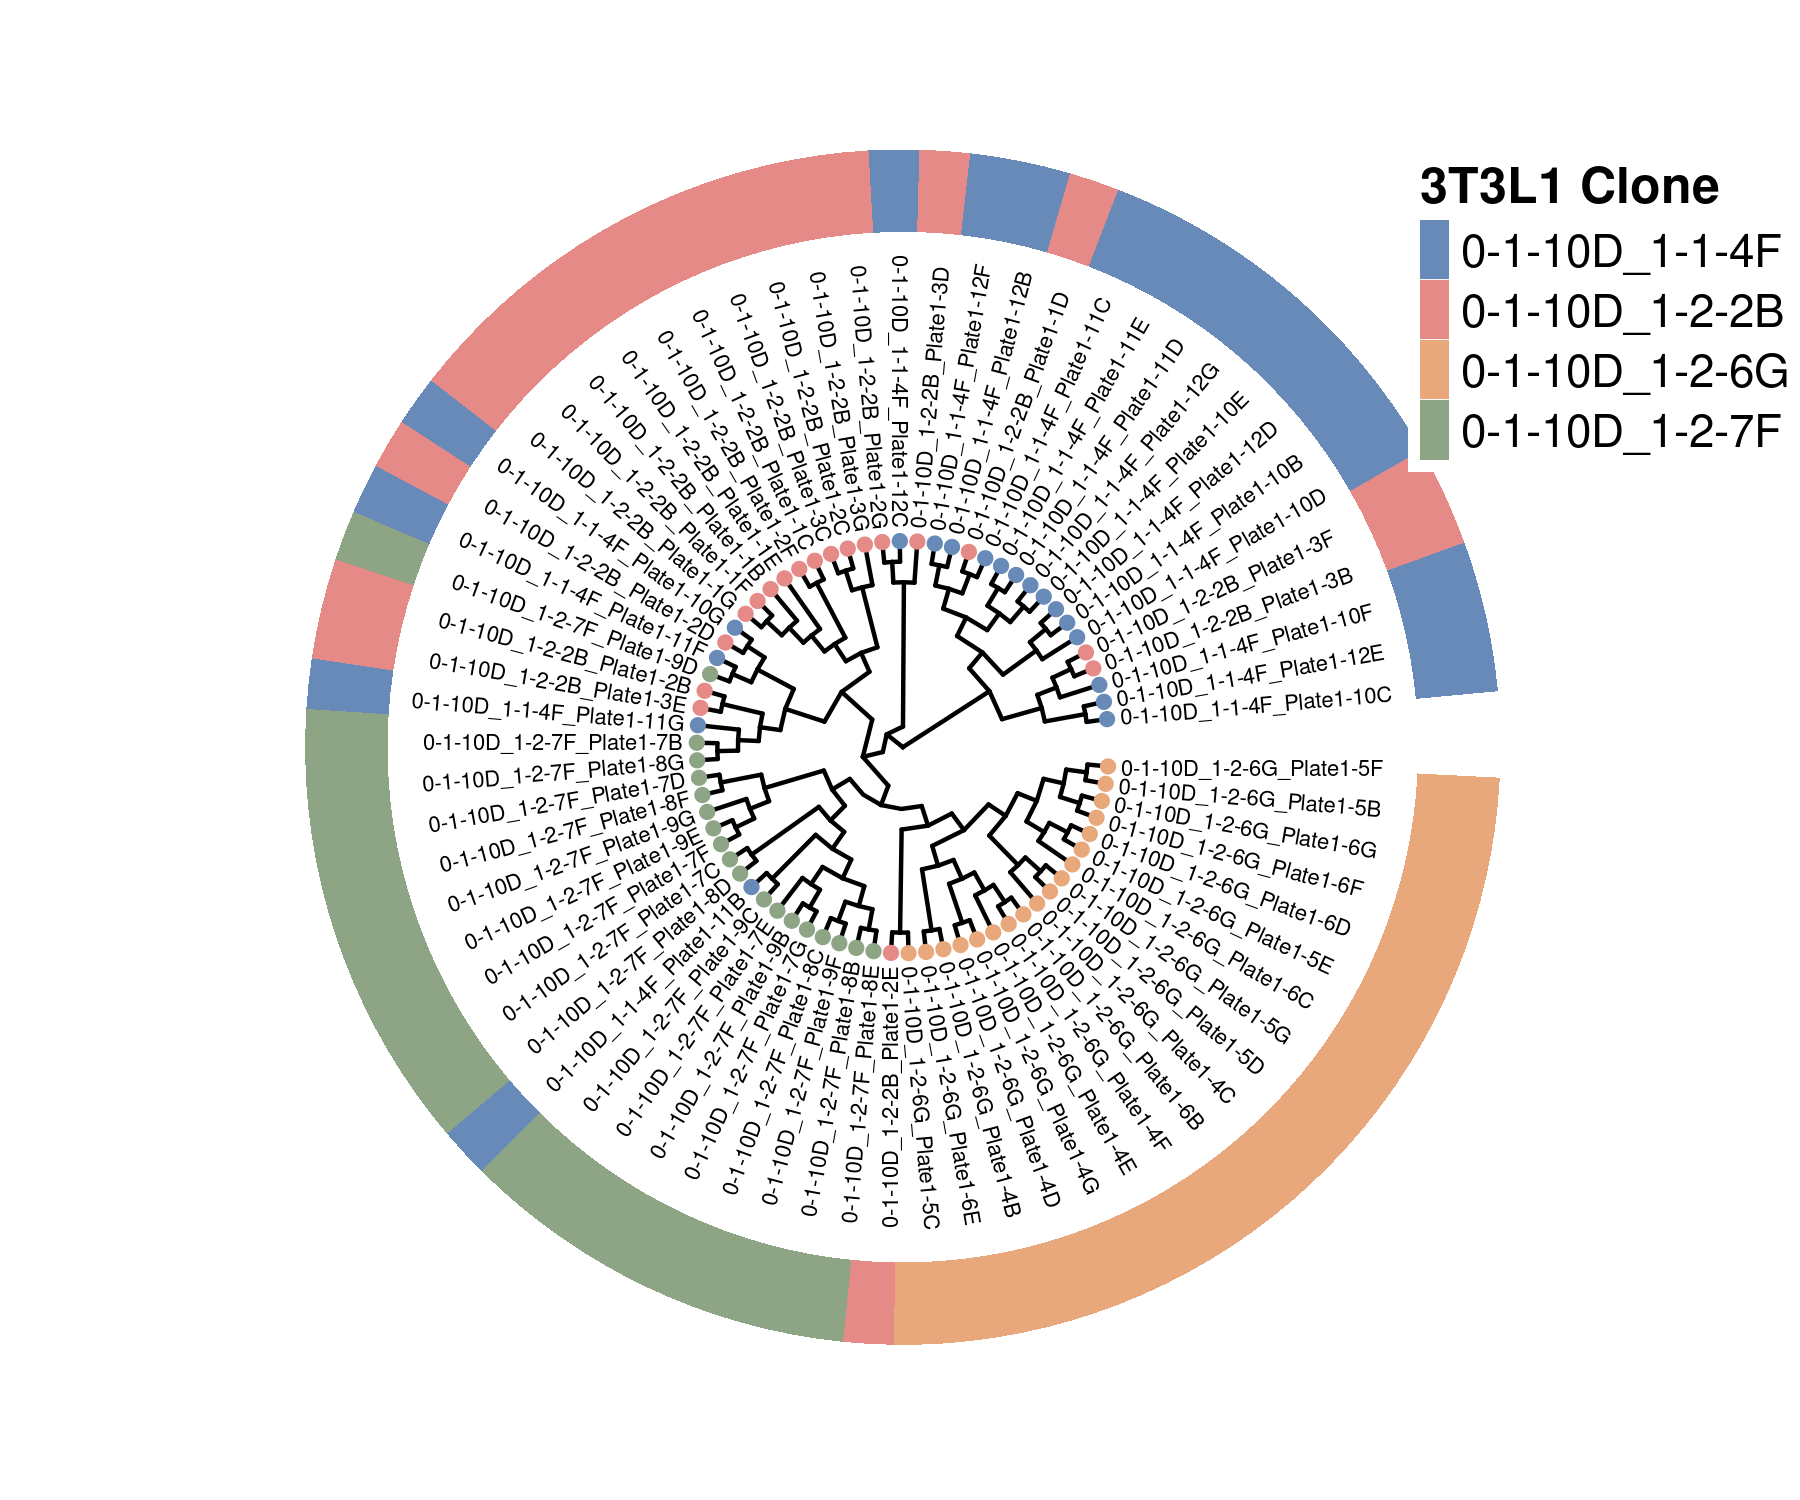

In [29]:
# Adjust plot margins and theme, and position legends
p <- p + theme(
  plot.margin = margin(0, 0, 0, 0),  # Remove all margins
  legend.text = element_text(size = LEGEND_TEXT_SIZE),  # Larger legend text
  legend.title = element_text(size = LEGEND_TITLE_SIZE, face = "bold"),  # Larger, bold legend titles
  legend.background = element_rect(fill = "white", colour = NA),  # White background, no border
  legend.position = c(1.1, 0.9),  # Position at upper right (x, y from 0-1)
  legend.justification = c(1, 1)  # Anchor at top-right corner of legend box
)

cat("Applied final theming\n")

# Display the plot
print(p)


In [30]:
# Save outputs
ggsave(paste0(OUTPUT_PREFIX, '.viewPhylo.pdf'), p, width = PLOT_WIDTH, height = PLOT_HEIGHT, dpi = DPI)
ggsave(paste0(OUTPUT_PREFIX, '.viewPhylo.png'), p, width = PLOT_WIDTH, height = PLOT_HEIGHT, dpi = DPI)

cat("Tree visualization saved to:\n")
cat(paste0("  ", OUTPUT_PREFIX, ".viewPhylo.pdf\n"))
cat(paste0("  ", OUTPUT_PREFIX, ".viewPhylo.png\n"))


Tree visualization saved to:
  20240319_3T3L1_10000targets_minqual0.9_circular_ggtree.viewPhylo.pdf
  20240319_3T3L1_10000targets_minqual0.9_circular_ggtree.viewPhylo.png
